<a href="https://colab.research.google.com/github/ngocnhihophuong2599-max/TH_Deep/blob/main/tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

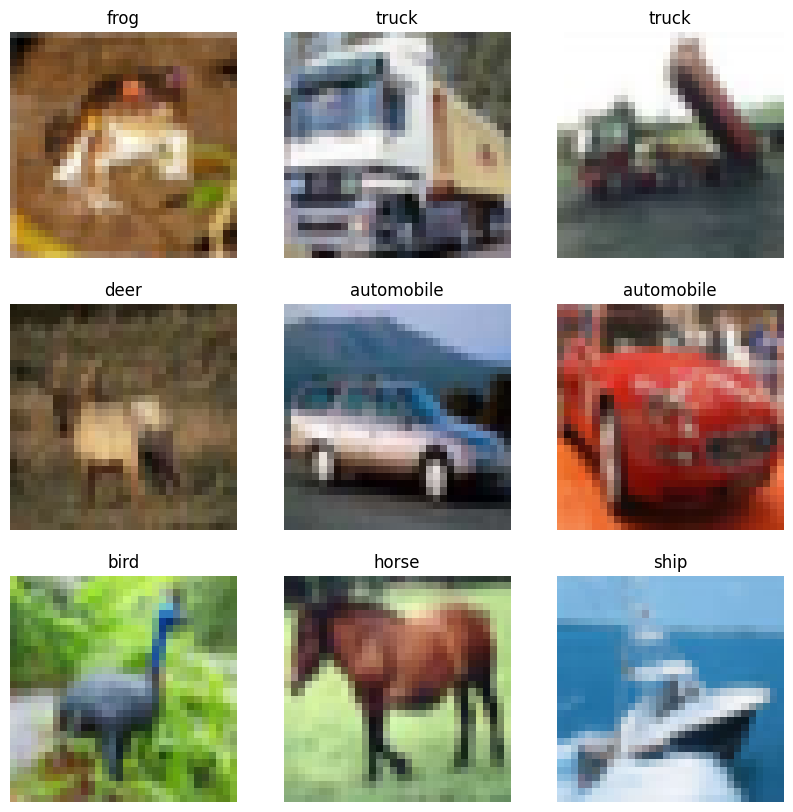

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3120 - loss: 1.8928 - val_accuracy: 0.3832 - val_loss: 1.7217
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3930 - loss: 1.6856 - val_accuracy: 0.3880 - val_loss: 1.7071
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4274 - loss: 1.5964 - val_accuracy: 0.4202 - val_loss: 1.5895
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4523 - loss: 1.5275 - val_accuracy: 0.4584 - val_loss: 1.4941
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4659 - loss: 1.4921 - val_accuracy: 0.4611 - val_loss: 1.5048
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4811 - loss: 1.4512 - val_accuracy: 0.4619 - val_loss: 1.4987
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4931 - loss: 1.4232 - val_accuracy: 0.4603 - val_loss: 1.5150
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5018 - loss: 1.3963 - val_accuracy: 0.

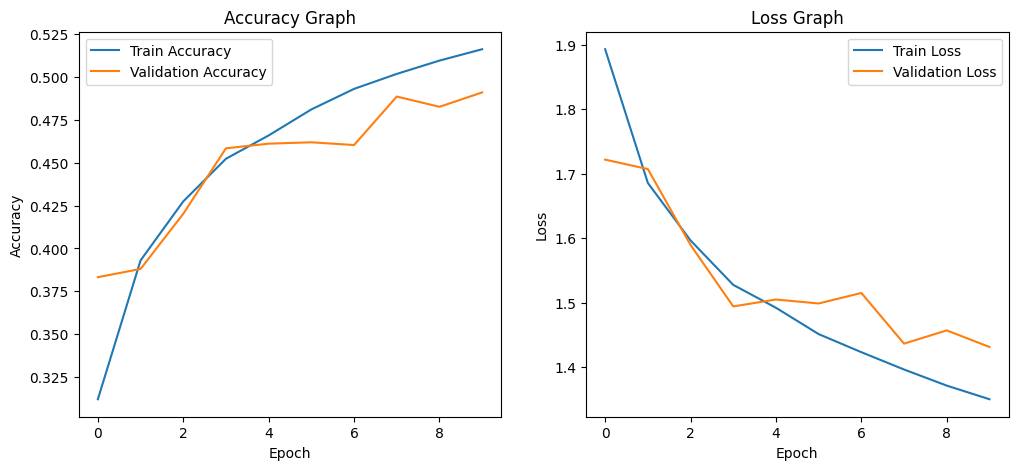

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


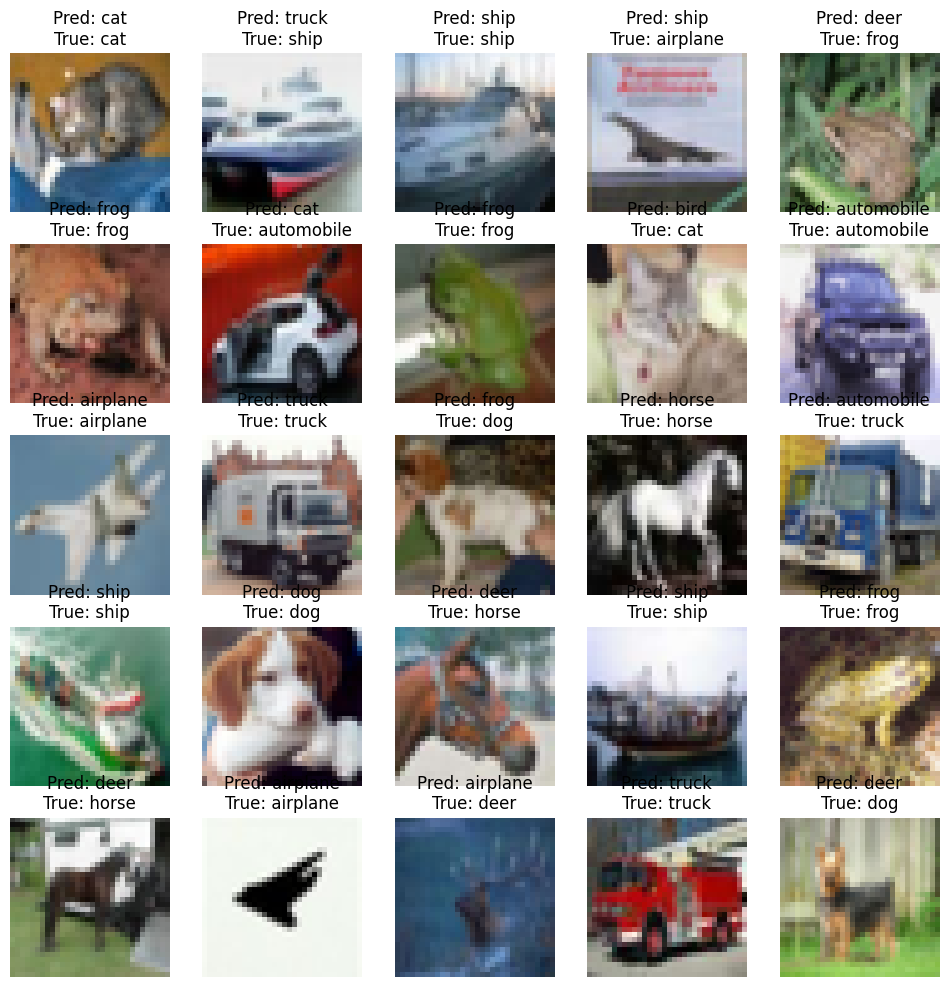

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

x_train = x_train / 255.0
x_test = x_test / 255.0


plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

model = models.Sequential([
    tf.keras.Input(shape=(32, 32, 3)), # Define input shape using Input layer
    layers.Flatten() # Flatten layer no longer needs input_shape
])

# Hidden Layer 1
model.add(layers.Dense(512, activation='relu'))

# Hidden Layer 2
model.add(layers.Dense(256, activation='relu'))

# Hidden Layer 3
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)


test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nĐộ chính xác trên tập test:", test_acc)
plt.figure(figsize=(12,5))

# Accuracy

plt.subplot(1,2,1)

plt.plot(
history.history['accuracy'],
label='Train Accuracy'
)

plt.plot(
history.history['val_accuracy'],
label='Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Accuracy Graph')

plt.legend()

# Loss

plt.subplot(1,2,2)

plt.plot(
history.history['loss'],
label='Train Loss'
)

plt.plot(
history.history['val_loss'],
label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Loss Graph')

plt.legend()

plt.show()

predictions = model.predict(x_test)

plt.figure(figsize=(12,12)) # Adjusted figure size for 5x5 grid

for i in range(25):

    plt.subplot(5,5,i+1) # Changed subplot to 5x5

    plt.imshow(x_test[i])

    predicted_label = np.argmax(predictions[i])

    true_label = y_test[i][0]

    plt.title(
        f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}"
    )

    plt.axis('off')

plt.show()